In [8]:
from experiments.dj.likelihood_tables import LikelihoodConfig
from experiments.dj.result_tables import (
    AdaptPriorResult,
    FlowPriorResult,
    LikelihoodResult,
)
from pathlib import Path
from experiments.dj.prior_tables import FlowPriorConfig
from experiments.dj.trainer_tables import FPTrainerConfig, LLTrainerConfig
from experiments.dj.dataloader_tables import DataLoaderConfig
from experiments.dj.dj_helpers import fetch_best_model_results
import gensn.distributions as G
import torch
from task_transfer.ml_lib.data_loading import build_dataloaders
from task_transfer.evaluation.evaluate_generative_model import (
    evaluate_flow_prior,
    compute_logl,
    adapt_prior_eval_criterion,
    compute_joint_logl,
    logl_mc_marginal_eval,
)


from experiments.dj.posterior_tables import SBVGPConfig

from experiments.dj.sysident_tables import SIConfig
from experiments.dj.result_tables import (
    SBVGPResult,
    SIResult,
    FlowPriorResult,
    AdaptPriorResult,
)
from experiments.dj.dataloader_tables import DataLoaderConfig

from task_transfer.utils.insilico_stimuli import generate_gabors
from task_transfer.ml_lib.data_loading import build_dataloaders

from task_transfer.evaluation.evaluate_generative_model import compute_logl
from task_transfer.evaluation.evaluate_generative_model import (
    compute_logl_marginal,
    compute_logl_data_marginal,
)
import torch
import matplotlib.pyplot as plt
import seaborn as sns


import numpy as np
from task_transfer.utils.math_utils import cos2_von_mises

from task_transfer.utils.model_utils import build_haefner_model

torch.manual_seed(42)

import experiments.orientation_discrimination.haefner_model.configs as cfg

In [3]:
restriction = "dl_id = '592885da0624c8a8c3073ec47d9bcfba'"

AdaptPriorResult & restriction

seed,prior_fp_id to index into FlowPriorConfig,prior_trainer_id to index into FPTrainerConfig,likelihood_id to index into LikelihoodConfig,likelihood_trainer_id to index into LLTrainerConfig,orig_dl_id to index into DataLoaderConfig used for the prior and likelihood training,trainer_id,dl_id,"train_marginal_obs_ll_mean mean per trial, per sample, in nats",train_marginal_obs_ll_sem standard error of the mean,val_marginal_obs_ll_mean,val_marginal_obs_ll_sem,test_marginal_obs_ll_mean,test_marginal_obs_ll_sem,"train_prior_ll_mean mean per trial, per sample, in nats",train_prior_ll_sem standard error of the mean,val_prior_ll_mean,val_prior_ll_sem,test_prior_ll_mean,test_prior_ll_sem,tracker_output,eval_output,model trained joint model NOT just the prior
42,89c1053a65023b042dc63f7f852bb5b0,c40a50ce9c77369770dddd5129836477,a67b8eaff13e89e7272e90768c2ab280,f89651063b51487dcdf4041336ef89db,f1ae78885d2ace1ba976199d4cf1a4d6,132c5a41de356eda4032103ef56e8126,592885da0624c8a8c3073ec47d9bcfba,123.73670959472656,1.2283427715301514,123.60498809814453,2.1535303592681885,123.30770111083984,3.184892416000366,-1.1685525178909302,0.14270377159118652,-1.156842589378357,0.26146644353866577,-1.181787371635437,0.3882736265659332,=BLOB=,=BLOB=,=BLOB=


In [4]:
adapted_prior = (AdaptPriorResult & restriction).fetch(
    download_path="/tmp",
    order_by="val_marginal_obs_ll_mean DESC",
    limit=1,
    as_dict=True,
)[0]

In [5]:
adapted_prior_model = torch.load(adapted_prior["model"], map_location="cpu")

In [16]:
# download_path = "/tmp"
# criterion = "val_ll_mean"
# k = 1

# prior_config_proj_col = "fp_id"
# dataloader_restriction = "dl_id = ''"
# best_val_prior_results = fetch_best_model_results(
#     result_table=FlowPriorResult,
#     config_table=FlowPriorConfig,
#     data_loader_config_table=DataLoaderConfig,
#     trainer_config_table=FPTrainerConfig,
#     config_proj_col=prior_config_proj_col,
#     criterion=criterion,
#     k=k,
#     download_path=download_path,
# )
# prior_model = torch.load(best_val_prior_results["model"], map_location="cpu")

# # get likelihood model for marginal likelihood
# likelihood_config_proj_col = "ll_id"
# best_val_likelihood_results = fetch_best_model_results(
#     result_table=LikelihoodResult,
#     config_table=LikelihoodConfig,
#     data_loader_config_table=DataLoaderConfig,
#     trainer_config_table=LLTrainerConfig,
#     config_proj_col=likelihood_config_proj_col,
#     criterion=criterion,
#     k=k,
#     download_path=download_path,
# )
# likelihood_model = torch.load(best_val_likelihood_results["model"], map_location="cpu")

dataloader_args = {
    "data_fname": "/src/project/data/synthetic/haefner_2afc/haefner_model_1neuron_task2_dataset.pkl",
    "train_prop": 0.7,
    "val_prop": 0.2,
}
train_loader, val_loader, test_loader = build_dataloaders(
    data_fname=dataloader_args["data_fname"],
    train_prop=dataloader_args["train_prop"],
    val_prop=dataloader_args["val_prop"],
    batch_size=128,
)

# joint_model = G.Joint(prior=prior_model, conditional=likelihood_model)

In [6]:
haefner_model = build_haefner_model(
    p_c=cfg.haefner_model_1neuron_task2["p_c"],
    c1_psi=cfg.haefner_model_1neuron_task2["c1_psi"],
    c2_psi=cfg.haefner_model_1neuron_task2["c2_psi"],
    kappa=cfg.haefner_model_1neuron_task2["kappa"],
    g_phi=cfg.haefner_model_1neuron_task2["g_phi"],
    delta=cfg.haefner_model_1neuron_task2["delta"],
    lam=cfg.haefner_model_1neuron_task2["lam"],
    x_phi=cfg.haefner_model_1neuron_task2["x_phi"],
    obs_sigma=cfg.haefner_model_1neuron_task2["obs_sigma"],
    obs_h=cfg.haefner_model_1neuron_task2["obs_h"],
    obs_w=cfg.haefner_model_1neuron_task2["obs_w"],
)

In [7]:
def haefner_prior_sampling_fn(haefner_model, n_samples):
    samples = haefner_model.sample_prior(n_samples=n_samples)
    return samples["x_samples"]

In [12]:
adapted_prior_model

Joint(
  (prior): FlowDistribution(
    (base_distribution): TrainableDistributionAdapter(
      distribution_class=<class 'torch.distributions.multivariate_normal.MultivariateNormal'>, loc=tensor([0.]), covariance_matrix=Covariance()
      (covariance_matrix): Covariance()
    )
    (transform): SequentialTransform(
      (transforms): ModuleList(
        (0): InverseTransform(
          (transform): Softplus()
        )
        (1): IndependentAffine()
        (2): Tanh()
        (3): IndependentAffine()
        (4): Tanh()
        (5): IndependentAffine()
      )
    )
  )
  (conditional): IndependentNormal(
    (trainable_distribution): IndependentTrainableDistributionAdapter(
      distribution_class=<class 'torch.distributions.normal.Normal'>, event_dims=1
      (parameter_generator): LocScale(
        (core_nn): MLP(
          (core_module): Sequential(
            (linear_0): Linear(in_features=1, out_features=144, bias=True)
            (dropout_0): Dropout(p=0.0, inplace=Fals

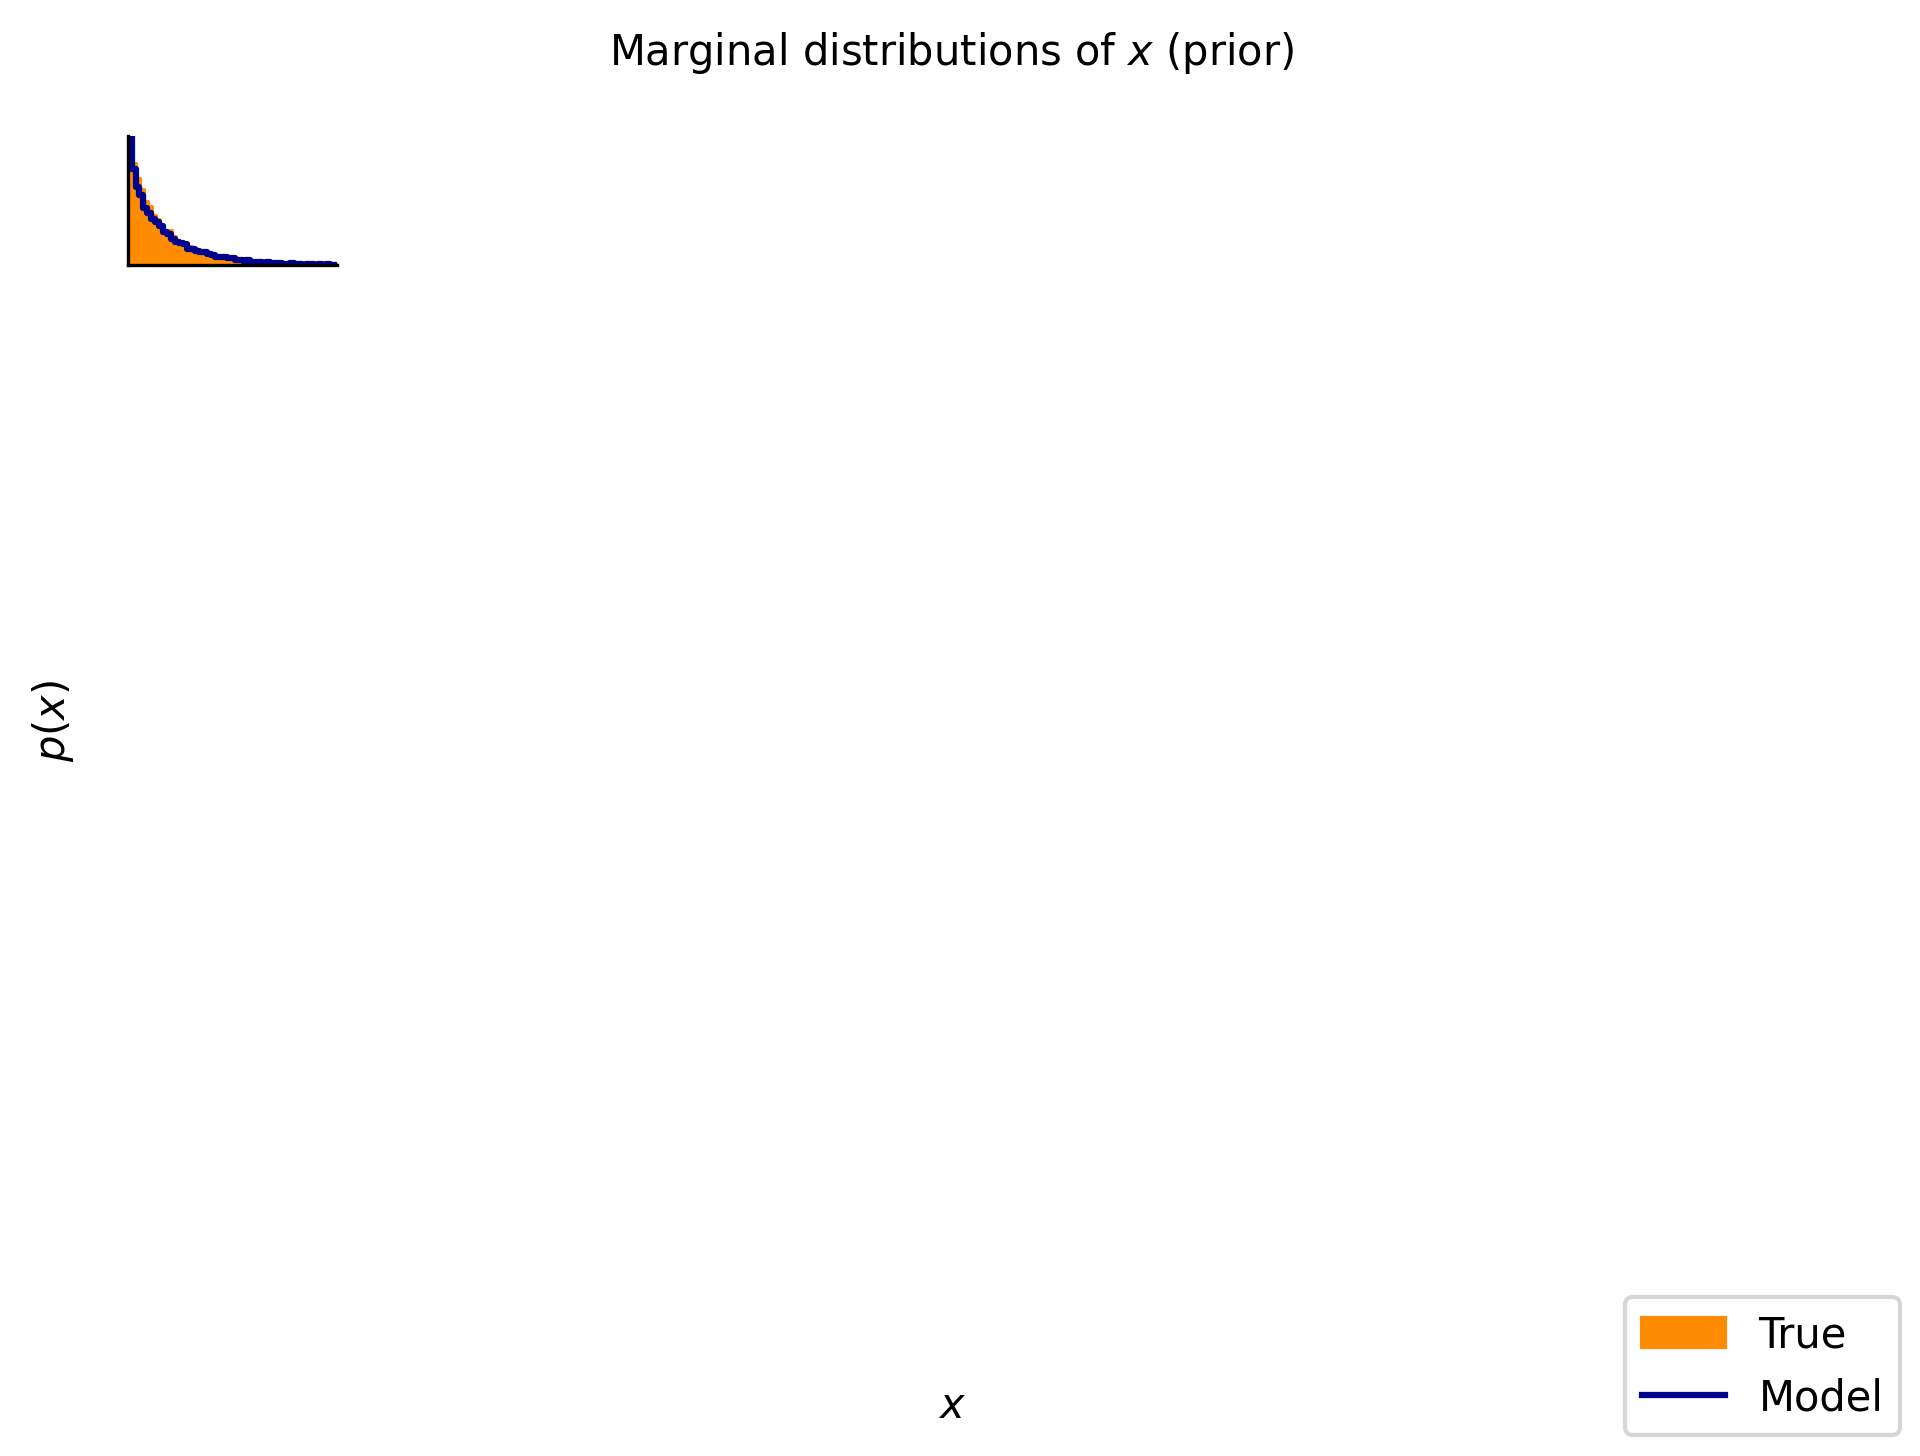

RuntimeError: tril: input tensor must have at least 2 dimensions

In [17]:
output = evaluate_flow_prior(
    adapted_prior_model.prior,
    train_loader,
    plot_params=dict(
        dims_to_plot=range(1),
        fig_dpi=300,
        linewidth=3,
        tick_length=6,
        tick_width=2,
        fontsize=10,
        plot_xlim=(0, 7),
        plot_ylim=(0, 1),
        density_color="darkblue",
        data_color="darkorange",
        data_alpha=1.0,
        sample_color="darkblue",
        sample_alpha=1.0,
        fig_save_dir=Path("/src/project/figures/learning/"),
    ),
)